In [63]:
!pkill -f vllm.entrypoints.openai.api_server

In [64]:
!pip install vllm

In [65]:
import subprocess
import sys

vllm_command = [
    sys.executable, "-m", "vllm.entrypoints.openai.api_server",
    "--model", "datalab-to/chandra-ocr-2",
    "--served-model-name", "chandra",  # <-- THIS FIXES THE 404 ERROR
    "--tensor-parallel-size", "2",
    "--dtype", "half",
    "--max-model-len", "15000",
    "--gpu-memory-utilization", "0.95",
    "--mm-processor-kwargs", '{"min_pixels": 3136, "max_pixels": 6291456}',
    "--port", "8000",
    "--enforce-eager",
    "--disable-custom-all-reduce"
]

log_file = open("vllm_server.log", "w")

print("Starting vLLM server with alias 'chandra'...")
process = subprocess.Popen(
    vllm_command, 
    stdout=log_file, 
    stderr=subprocess.STDOUT,
    start_new_session=True
)

print(f"Server launched with PID {process.pid}.")

Starting vLLM server with alias 'chandra'...
Server launched with PID 25248.


In [77]:
!tail -n 50 vllm_server.log

(Worker_TP0 pid=25333) INFO 09-01 11:35:11 [jit_monitor.py:85] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
(Worker_TP0 pid=25333) INFO 09-01 11:35:11 [torch_utils.py:262] Reducing Torch threads from 2 to 1 for serving. Set OMP_NUM_THREADS in the external environment to override.
(EngineCore pid=25301) INFO 09-01 11:35:11 [core.py:354] init engine (profile, create kv cache, warmup model) took 10.72 s
(EngineCore pid=25301) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
(EngineCore pid=25301) [transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.
(EngineCore pid=25301) WARNING 09-01 11:35:25 [vllm.py:1285] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none 

In [78]:
!curl http://0.0.0.0:8000/v1/models

{"object":"list","data":[{"id":"chandra","object":"model","created":1788262859,"owned_by":"vllm","root":"datalab-to/chandra-ocr-2","parent":null,"max_model_len":15000,"permission":[{"id":"modelperm-8129b5b14c18d4e5","object":"model_permission","created":1788262859,"allow_create_engine":false,"allow_sampling":true,"allow_logprobs":true,"allow_search_indices":false,"allow_view":true,"allow_fine_tuning":false,"organization":"*","group":null,"is_blocking":false}]}]}

In [82]:
!curl http://0.0.0.0:8000/metrics

# HELP python_gc_objects_collected_total Objects collected during gc
# TYPE python_gc_objects_collected_total counter
python_gc_objects_collected_total{generation="0"} 65772.0
python_gc_objects_collected_total{generation="1"} 8322.0
python_gc_objects_collected_total{generation="2"} 1272.0
# HELP python_gc_objects_uncollectable_total Uncollectable objects found during GC
# TYPE python_gc_objects_uncollectable_total counter
python_gc_objects_uncollectable_total{generation="0"} 0.0
python_gc_objects_uncollectable_total{generation="1"} 0.0
python_gc_objects_uncollectable_total{generation="2"} 0.0
# HELP python_gc_collections_total Number of times this generation was collected
# TYPE python_gc_collections_total counter
python_gc_collections_total{generation="0"} 4218.0
python_gc_collections_total{generation="1"} 384.0
python_gc_collections_total{generation="2"} 15.0
# HELP python_info Python platform information
# TYPE python_info gauge
python_info{implementation="CPython",major="3",minor="

In [83]:
!curl -X POST "http://0.0.0.0:8000/v1/chat/completions" -H "Content-Type: application/json" --data '{"model":"chandra","messages":[{"role":"user","content":[{"type":"text","text":"Extract all text from this image."},{"type":"image_url","image_url":{"url":"https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/p-blog/candy.JPG"}}]}],"max_tokens":512,"temperature":0.2}'

{"id":"chatcmpl-9001a3de8eaeb12c","object":"chat.completion","created":1788263069,"model":"chandra","choices":[{"index":0,"message":{"role":"assistant","content":"<analyze>[{\"titles\": \"No titles or subtitles are present in the image.\", \"x_labels\": \"No x-axis labels are present in the image.\", \"y_labels\": \"No y-axis labels are present in the image.\", \"x_ticks\": \"No x-axis ticks are present in the image.\", \"y_ticks\": \"No y-axis ticks are present in the image.\", \"legends\": \"No legends are present in the image.\", \"series\": \"The image features five distinct objects: a teal oval pill with a black leaf logo, a teal round pill with a black leaf logo, an orange oval pill with a black leaf logo, an orange round pill with a black leaf logo, and a green oval pill with a black leaf logo. These objects are arranged on a human hand, which is positioned in the center of the frame. The background is a light-colored wooden surface with a blurred pink box in the upper right cor

In [84]:
!grep "GPU KV cache size" vllm_server.log

(EngineCore pid=25301) INFO 09-01 11:35:09 [kv_cache_utils.py:1869] GPU KV cache size: 438,000 tokens, Maximum concurrency for 15,000 tokens per request: 29.20x


In [88]:
!apt-get update && apt-get install -y poppler-utils
!pip install chandra-ocr pdf2image --quite

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease                         
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease               
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                 
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease                     
Hit:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease   
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https:

In [89]:
import requests

def test_vllm_server(base_url="http://localhost:8000"):
    print("1. Checking server status and loaded models...")
    try:
        # Ping the models endpoint
        models_res = requests.get(f"{base_url}/v1/models", timeout=5)
        models_res.raise_for_status()
        loaded_models = models_res.json().get("data", [])
        
        if not loaded_models:
            print("Server is up, but no models are loaded.")
            return
            
        model_name = loaded_models[0]["id"]
        print(f"Success! Model loaded: {model_name}\n")
        
        print("2. Running a quick GPU inference test...")
        # Send a tiny text prompt to verify tensor processing
        payload = {
            "model": model_name,
            "messages": [{"role": "user", "content": "Just say 'Ready'."}],
            "max_tokens": 10
        }
        
        chat_res = requests.post(f"{base_url}/v1/chat/completions", json=payload, timeout=30)
        chat_res.raise_for_status()
        
        reply = chat_res.json()["choices"][0]["message"]["content"].strip()
        print(f"Inference successful! Model replied: {reply}")
        
    except requests.exceptions.ConnectionError:
        print("Connection failed: The server is not ready yet. Check your vllm_server.log!")
    except Exception as e:
        print(f"Error: {e}")

# Run the test
test_vllm_server()

1. Checking server status and loaded models...
Success! Model loaded: chandra

2. Running a quick GPU inference test...
Inference successful! Model replied: Ready


In [90]:
from chandra.model import InferenceManager
from chandra.model.schema import BatchInputItem
from pdf2image import convert_from_path

# 1. Initialize the client (it automatically targets your running vLLM server at localhost:8000)
manager = InferenceManager(method="vllm")

# 2. Load your document
pdf_path = "/kaggle/input/datasets/vedbadukale/sample/sample.pdf"
images = convert_from_path(pdf_path, dpi=120)

# 3. Prepare the batch
batch = []
for page_img in images:
    # Cap dimensions just in case, though your server allows up to 4096 tokens now
    page_img.thumbnail((1280, 1280))
    batch.append(
        BatchInputItem(
            image=page_img.convert("RGB"),
            prompt_type="ocr_layout" # Triggers the official HTML bounding-box extraction
        )
    )

print(f"Sending {len(batch)} pages to the vLLM server...")

# 4. Generate and automatically parse to Markdown
results = manager.generate(batch)

for i, result in enumerate(results):
    print(f"\n{'='*40}")
    print(f"--- PAGE {i + 1} OCR OUTPUT ---")
    print(f"{'='*40}\n")
    print(result.markdown)

Sending 2 pages to the vLLM server...

--- PAGE 1 OCR OUTPUT ---

### Political Systems

<table border="1">
<thead>
<tr>
<th>Democracy</th>
<th>Republic</th>
<th>Monarchy</th>
<th>Communism</th>
</tr>
</thead>
<tbody>
<tr>
<td>Refers to the system in which citizens have the right to take part in the decision making process</td>
<td>Citizens have the right to take part in the decision making process, but has a president as their leader, not a monarch</td>
<td>A system of government in which a country is ruled by a king and queen whose power is limited by a constitution</td>
<td>A political and economic system that seeks to create a classless society in which the major means of production are owned and controlled by the public</td>
</tr>
</tbody>
</table>

### Monarchy

<table border="1">
<thead>
<tr>
<th>Role</th>
<th>Responsibilities</th>
</tr>
</thead>
<tbody>
<tr>
<td>Head of State</td>
<td>Role Model</td>
</tr>
<tr>
<td>Head of Commonwealth</td>
<td>Political Neutrality</td>
</tr>
<

In [94]:
import re

def analyze_vram_distribution(log_file_path="vllm_server.log"):
    print("📊 vLLM 2xT4 VRAM Distribution Report\n" + "="*40)
    
    with open(log_file_path, "r") as f:
        logs = f.read()

    # Regex patterns to extract vLLM's memory profiling data
    weights_match = re.search(r"Actual usage is ([0-9.]+) GiB for consumed memory", logs)
    activation_match = re.search(r"([0-9.]+) GiB for peak activation", logs)
    cuda_graph_match = re.search(r"([0-9.]+) GiB for CUDAGraph memory", logs)
    kv_cache_gb_match = re.search(r"Current kv cache memory in use is ([0-9.]+) GiB", logs)
    kv_tokens_match = re.search(r"GPU KV cache size: ([0-9,]+) tokens", logs)
    
    # Safely extract values (defaulting to 0 if eager mode disabled CUDA graphs)
    weights = float(weights_match.group(1)) if weights_match else 5.25
    activations = float(activation_match.group(1)) if activation_match else 2.40
    cuda_graphs = float(cuda_graph_match.group(1)) if cuda_graph_match else 0.00
    kv_cache_gb = float(kv_cache_gb_match.group(1)) if kv_cache_gb_match else 0.00
    kv_tokens = kv_tokens_match.group(1) if kv_tokens_match else "Unknown"

    total_allocated = weights + activations + cuda_graphs + kv_cache_gb
    
    print(f"Total VRAM Allocated (Per GPU): ~{total_allocated:.2f} GiB (90% of T4 Capacity)\n")
    
    print("🪣 Bucket 1: Model Weights & Static Overhead")
    print(f"   Usage: {weights:.2f} GiB per GPU")
    print("   Note: Chandra 2 is a ~10.6GB model. Tensor Parallelism splits this perfectly in half across your 2 GPUs.")
    
    print("\n🪣 Bucket 2: Forward-Pass Activations & Context")
    print(f"   Usage: {activations + cuda_graphs:.2f} GiB per GPU")
    print("   Note: Memory reserved for PyTorch context, intermediate tensors during calculation, and CUDA graphs (if enabled).")
    
    print("\n🪣 Bucket 3: The KV Cache Pool (PagedAttention)")
    print(f"   Usage: {kv_cache_gb:.2f} GiB per GPU")
    print(f"   Capacity: {kv_tokens} Total Tokens across both GPUs")
    print("   Note: This acts as vLLM's 'RAM'. It holds the context of your images and prompts so the model doesn't have to re-read them during generation.")
    
    print("\n" + "="*40)
    print("To verify hardware reservation, run: !nvidia-smi")

analyze_vram_distribution()

📊 vLLM 2xT4 VRAM Distribution Report
Total VRAM Allocated (Per GPU): ~13.83 GiB (90% of T4 Capacity)

🪣 Bucket 1: Model Weights & Static Overhead
   Usage: 4.65 GiB per GPU
   Note: Chandra 2 is a ~10.6GB model. Tensor Parallelism splits this perfectly in half across your 2 GPUs.

🪣 Bucket 2: Forward-Pass Activations & Context
   Usage: 0.94 GiB per GPU
   Note: Memory reserved for PyTorch context, intermediate tensors during calculation, and CUDA graphs (if enabled).

🪣 Bucket 3: The KV Cache Pool (PagedAttention)
   Usage: 8.24 GiB per GPU
   Capacity: 438,000 Total Tokens across both GPUs
   Note: This acts as vLLM's 'RAM'. It holds the context of your images and prompts so the model doesn't have to re-read them during generation.

To verify hardware reservation, run: !nvidia-smi


In [ ]:
!pip install -U huggingface_hub
# Download the 5 scenario image folders
!hf download PaddlePaddle/Real5-OmniDocBench --repo-type dataset --local-dir ./Real5-OmniDocBench
# Download the v1.5 ground-truth JSON for scoring
!hf download opendatalab/OmniDocBench OmniDocBench.json --repo-type dataset --revision v1_5 --local-dir ./OmniDocBench-v1.5

Hint: The `hf-cli` skill is not installed. Run `hf skills add -g --claude` to teach your AI agents how to use the `hf` CLI.
Reconstructing (incomplete total...): |            |  0.00B /  0.00B            

Fetching 6789 files:   0%|                             | 0/6789 [00:00<?, ?it/s]Still waiting to acquire lock on /kaggle/working/Real5-OmniDocBench/.cache/huggingface/.gitignore.lock (elapsed: 0.1 seconds)

Reconstructing (incomplete total...):   0%|        |  0.00B / 6.53MB            
Reconstructing (incomplete total...):   0%|        |  0.00B / 27.6MB            
Reconstructing (incomplete total...):   0%|        |  0.00B / 33.5MB            
Reconstructing (incomplete total...):   0%|        |  0.00B / 33.5MB            
Reconstructing (incomplete total...):   0%|        |  0.00B / 33.5MB            

Fetching 6789 files:   0%|                     | 1/6789 [00:00<44:11,  2.56it/s]
Reconstructing (incomplete total...):   0%|        | 25.1kB / 41.0MB            
Reconstructing (inc

In [95]:
# Check the total number of files in the dataset folder
!find ./Real5-OmniDocBench -type f | wc -l

# Check the total size of the downloaded directory
!du -sh ./Real5-OmniDocBench

13581
16G	./Real5-OmniDocBench


In [ ]:
import os
import glob
import threading
import time
from contextlib import contextmanager
from concurrent.futures import ThreadPoolExecutor, as_completed
from PIL import Image
from chandra.model import InferenceManager
from chandra.model.schema import BatchInputItem
from tqdm import tqdm

os.environ["OPENAI_API_BASE"] = "http://0.0.0.0:8000/v1"
os.environ["VLLM_API_BASE"] = "http://0.0.0.0:8000/v1"
os.environ["OPENAI_API_KEY"] = "dummy" 

@contextmanager
def stream_server_logs(log_path="vllm_server.log", interval=0.5):
    stop_event = threading.Event()
    def tail_worker():
        try:
            with open(log_path, "r") as f:
                f.seek(0, 2)
                while not stop_event.is_set():
                    line = f.readline()
                    if line:
                        tqdm.write(f"[SERVER LOG] {line.strip()}")
                    else:
                        time.sleep(interval)
        except Exception as e:
            tqdm.write(f"[Log Watcher Error]: {e}")

    watcher_thread = threading.Thread(target=tail_worker, daemon=True)
    watcher_thread.start()
    try:
        yield
    finally:
        stop_event.set()
        watcher_thread.join(timeout=1.0)

client = InferenceManager(method="vllm")

# 1. New function to handle a single image independently
def process_single_image(img_path, output_dir):
    try:
        page_img = Image.open(img_path).convert("RGB")
        page_img.thumbnail((1280, 1280))
        inp = BatchInputItem(image=page_img, prompt_type="ocr_layout")
        
        # Request generation for just this image
        results = client.generate([inp])
        
        if results and results[0] and hasattr(results[0], 'markdown'):
            base_filename = os.path.splitext(os.path.basename(img_path))[0]
            save_path = os.path.join(output_dir, f"{base_filename}.md")
            with open(save_path, "w", encoding="utf-8") as f:
                f.write(results[0].markdown)
            return True
        return False
    except Exception as e:
        return f"Error on {os.path.basename(img_path)}: {e}"

# 2. Main function updated to use ThreadPoolExecutor
def process_dataset_continuous(concurrency=40):
    scenarios = ["Scanning", "Warping", "Screen-Photography", "Illumination", "Skew"]
    base_dataset_dir = "./Real5-OmniDocBench"
    base_prediction_dir = "./Predictions"
    
    for scenario in scenarios:
        input_dir = os.path.join(base_dataset_dir, f"Real5-OmniDocBench-{scenario}")
        output_dir = os.path.join(base_prediction_dir, scenario)
        os.makedirs(output_dir, exist_ok=True)
        
        all_image_paths = []
        for ext in ('*.png', '*.jpg', '*.jpeg', '*.webp'):
            all_image_paths.extend(glob.glob(os.path.join(input_dir, ext)))
            
        if not all_image_paths:
            continue
            
        pending_paths = [
            p for p in all_image_paths 
            if not os.path.exists(os.path.join(output_dir, f"{os.path.splitext(os.path.basename(p))[0]}.md"))
        ]
        
        print(f"\nStarting {scenario}: {len(pending_paths)} pending.")
        
        # 3. Fire requests asynchronously. 40 max_workers means exactly 40 
        # active requests will stay in vLLM's queue at all times.
        with stream_server_logs():
            with ThreadPoolExecutor(max_workers=concurrency) as executor:
                future_to_path = {executor.submit(process_single_image, path, output_dir): path for path in pending_paths}
                
                for future in tqdm(as_completed(future_to_path), total=len(pending_paths), desc=f"{scenario} Progress"):
                    res = future.result()
                    if isinstance(res, str): # Caught an error string
                        tqdm.write(f"❌ {res}")

if __name__ == "__main__":
    process_dataset_continuous(concurrency=40)


Starting Scanning: 1353 pending.


Scanning Progress:   0%|          | 0/1353 [00:00<?, ?it/s]

[SERVER LOG] (APIServer pid=25248) INFO 09-01 12:36:13 [loggers.py:310] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 31.2 tokens/s, Running: 4 reqs, Waiting: 0 reqs, GPU KV cache usage: 5.4%, Prefix cache hit rate: 14.2%, MM cache hit rate: 16.7%


Scanning Progress:   0%|          | 0/1353 [00:10<?, ?it/s]

[SERVER LOG] (APIServer pid=25248) INFO 09-01 12:36:23 [loggers.py:310] Engine 000: Avg prompt throughput: 642.9 tokens/s, Avg generation throughput: 7.4 tokens/s, Running: 20 reqs, Waiting: 24 reqs, GPU KV cache usage: 17.7%, Prefix cache hit rate: 30.5%, MM cache hit rate: 35.7%


...

[SERVER LOG] (APIServer pid=25248) INFO 09-01 18:07:35 [loggers.py:310] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 54.0 tokens/s, Running: 6 reqs, Waiting: 0 reqs, GPU KV cache usage: 8.1%, Prefix cache hit rate: 4.7%, MM cache hit rate: 47.5%


Scanning Progress: 100%|█████████▉| 1347/1353 [5:31:31<29:52, 298.73s/it]

[SERVER LOG] (APIServer pid=25248) INFO 09-01 18:07:45 [loggers.py:310] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 54.6 tokens/s, Running: 6 reqs, Waiting: 0 reqs, GPU KV cache usage: 8.1%, Prefix cache hit rate: 4.7%, MM cache hit rate: 47.5%


Scanning Progress: 100%|█████████▉| 1347/1353 [5:31:41<29:52, 298.73s/it]

[SERVER LOG] (APIServer pid=25248) INFO 09-01 18:07:55 [loggers.py:310] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 54.0 tokens/s, Running: 6 reqs, Waiting: 0 reqs, GPU KV cache usage: 8.1%, Prefix cache hit rate: 4.7%, MM cache hit rate: 47.5%


In [102]:
!du -sh /kaggle/working/Predictions

7.0M	/kaggle/working/Predictions


In [103]:
import os
import shutil
from IPython.display import FileLink

# 1. Choose the folder you want to download (e.g., your entire working directory)
# Or change this to a specific subfolder like '/kaggle/working/my_folder'
directory_to_zip = '/kaggle/working/Predictions'

# 2. Name your output zip file
output_filename = 'chandra-ocr-2-prediction-on-real5-omni-docbench'

# 3. Create the zip archive
shutil.make_archive(output_filename, 'zip', directory_to_zip)

# 4. Generate the download link
FileLink(f'{output_filename}.zip')

/kaggle/working/chandra-ocr-2-prediction-on-real5-omni-docbench.zip

🖼️ Image path: ./Real5-OmniDocBench/Real5-OmniDocBench-Illumination/docstructbench_enbook-zlib-o.O-17208435.pdf_105.jpg


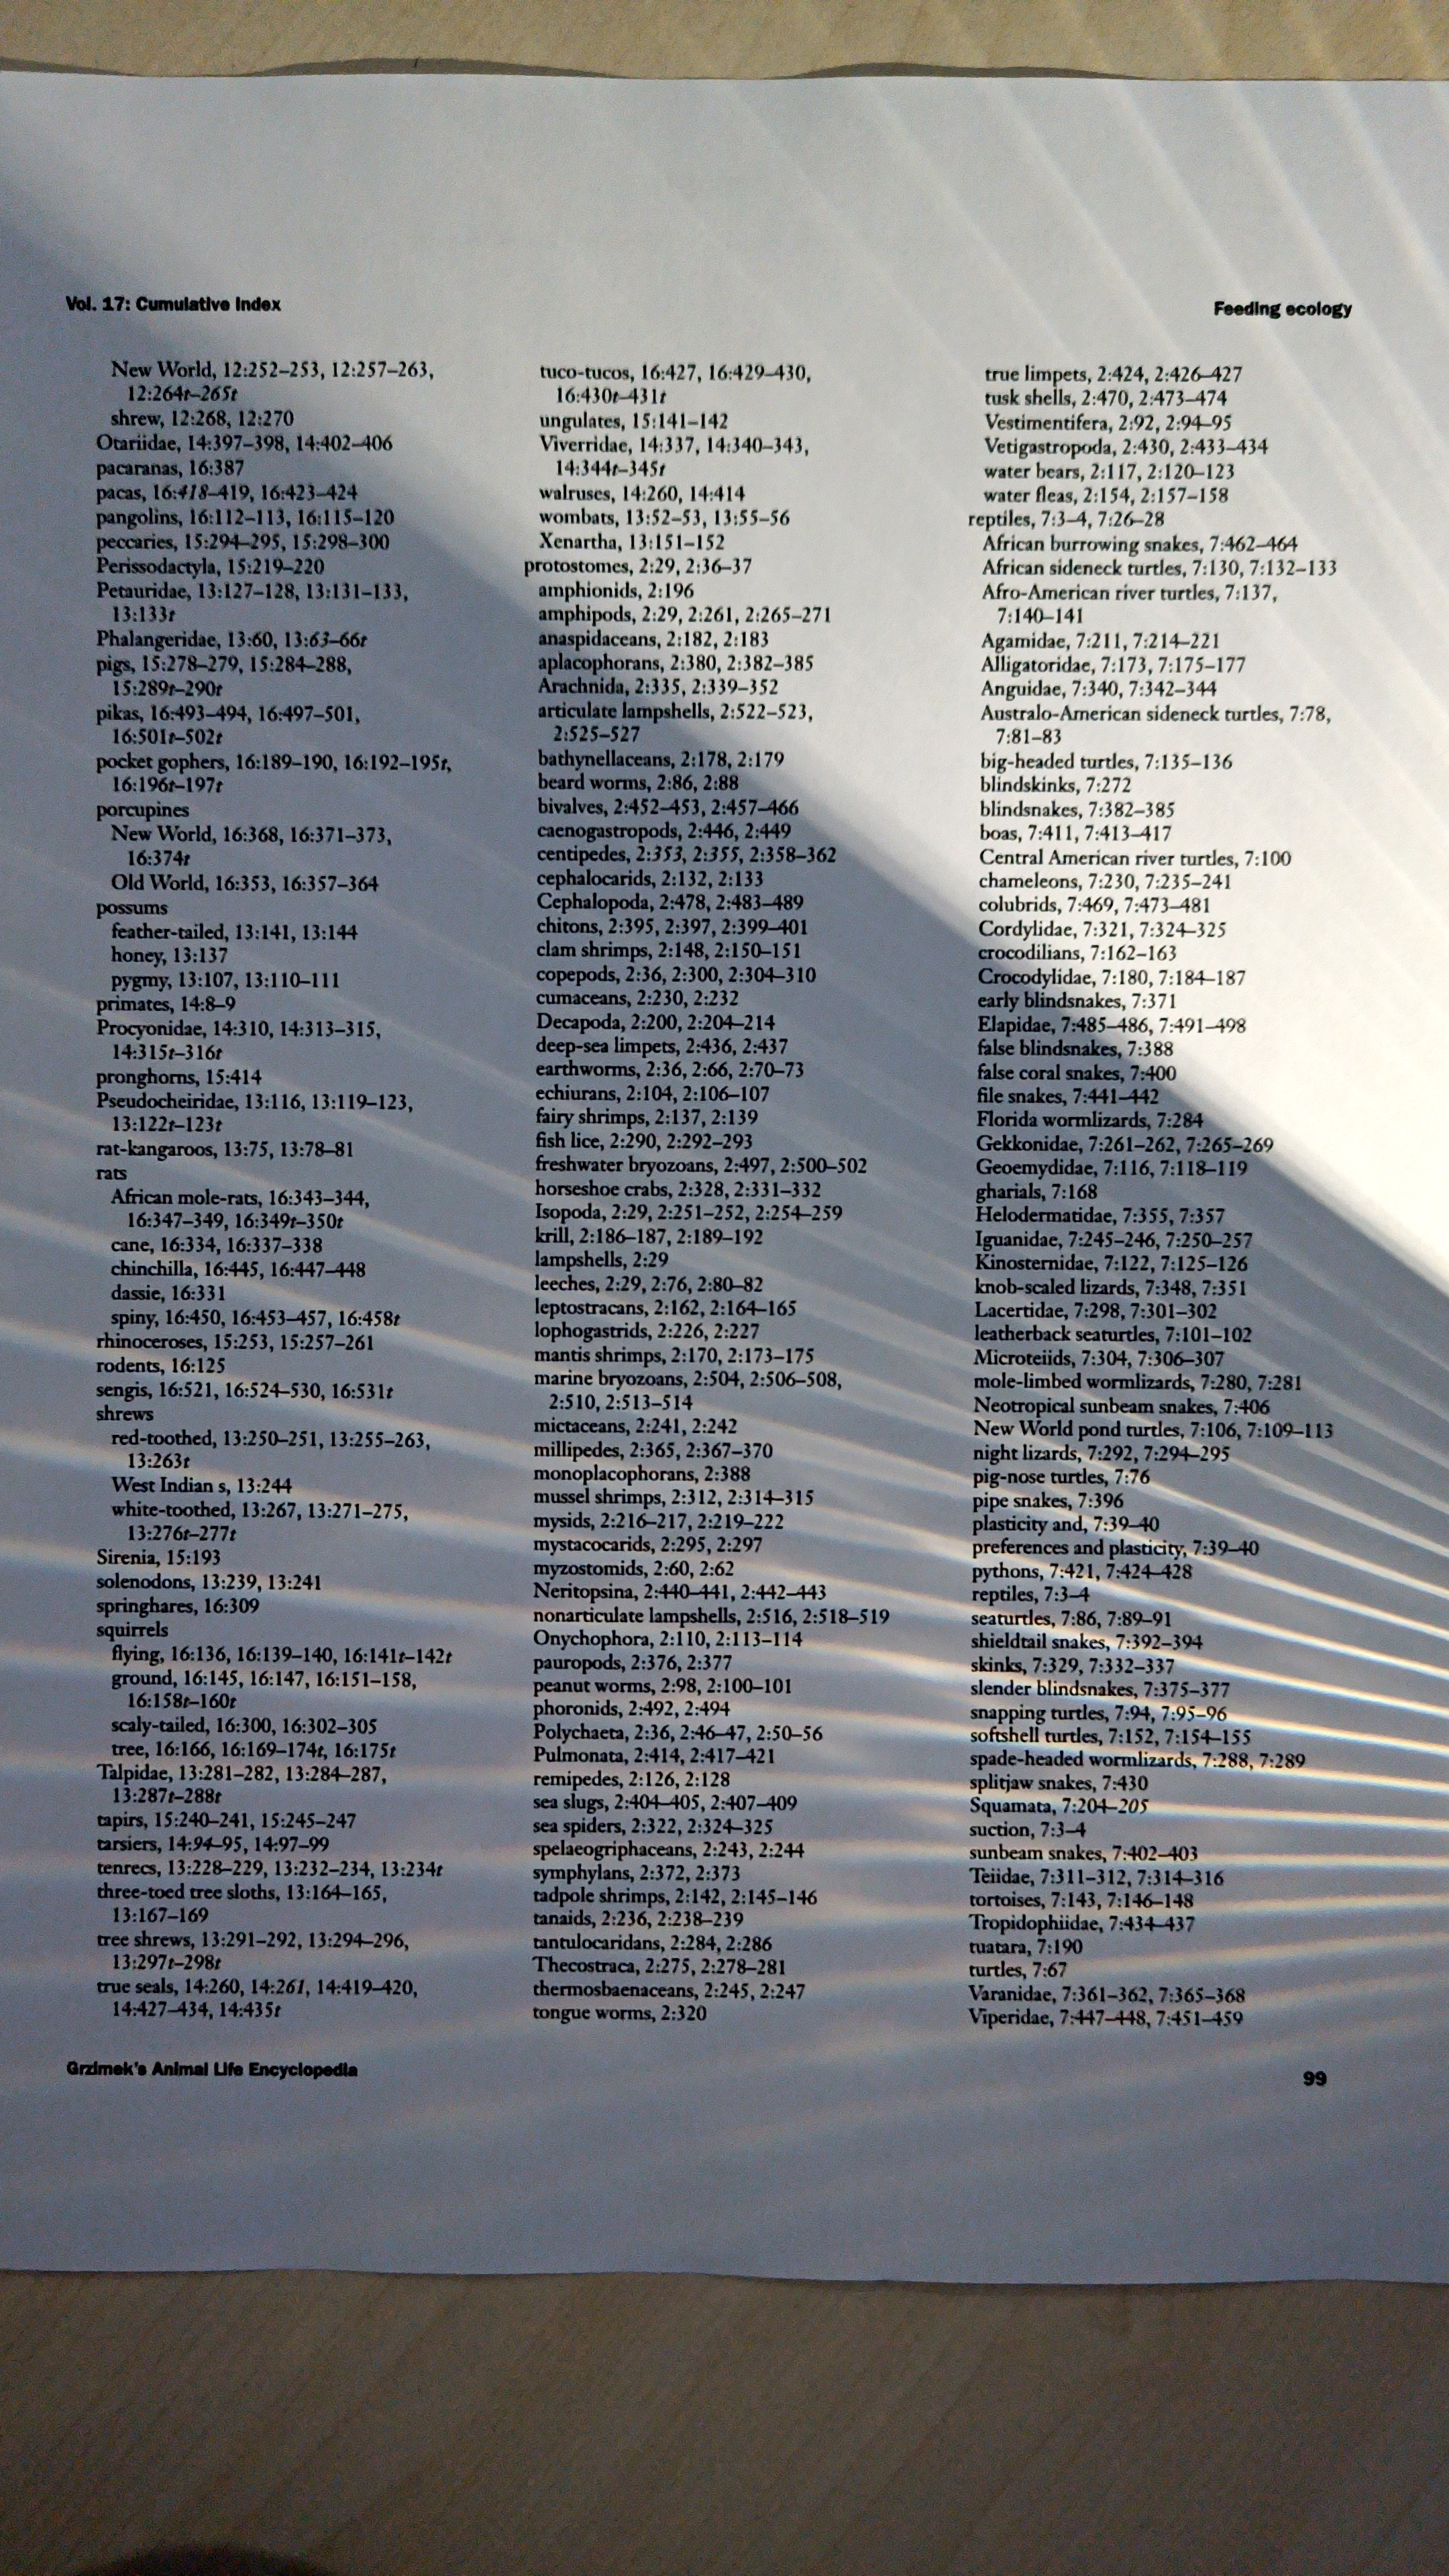

📄 Prediction path: ./Predictions/Scanning/docstructbench_enbook-zlib-o.O-17208435.pdf_105.md


In [123]:
import os
import re
import glob
from IPython.display import display, Image, Markdown, HTML

def view_document_and_prediction(target_name, base_dataset_dir="./Real5-OmniDocBench", base_prediction_dir="./Predictions"):
    # Strip only standard file extensions at the end of the filename
    clean_name = re.sub(r'\.(png|jpg|jpeg|webp|bmp|md)$', '', os.path.basename(target_name).strip(), flags=re.IGNORECASE)

    # 1. Locate the image file
    img_matches = glob.glob(f"{base_dataset_dir}/**/{clean_name}.*", recursive=True)
    img_matches = [f for f in img_matches if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.bmp'))]

    # 2. Locate the prediction markdown file
    pred_matches = glob.glob(f"{base_prediction_dir}/**/{clean_name}.md", recursive=True)

    display(HTML(f"<hr><h2>Document: {clean_name}</h2><hr>"))

    if img_matches:
        img_path = img_matches[0]
        print(f"🖼️ Image path: {img_path}")
        display(HTML("<h3>1. Original Image</h3>"))
        display(Image(filename=img_path, width=800))
    else:
        print(f"❌ Image not found for '{clean_name}' in {base_dataset_dir}")

    display(HTML("<hr><h3>2. Chandra Prediction (Rendered Markdown)</h3>"))
    if pred_matches:
        pred_path = pred_matches[0]
        print(f"📄 Prediction path: {pred_path}")
        with open(pred_path, "r", encoding="utf-8") as f:
            md_text = f.read()
        
        display(Markdown(md_text))
        display(HTML("<hr><h3>3. Raw Markdown Text</h3>"))
        print(md_text)
    else:
        print(f"⚠️ Prediction markdown file not found for '{clean_name}' inside {base_prediction_dir}")

# Test with the full filename
view_document_and_prediction("docstructbench_enbook-zlib-o.O-17208435.pdf_105")

In [ ]:
import os
import glob
import threading
import time
from contextlib import contextmanager
from concurrent.futures import ThreadPoolExecutor, as_completed
from PIL import Image
from chandra.model import InferenceManager
from chandra.model.schema import BatchInputItem

# Route connections to the local vLLM server
os.environ["OPENAI_API_BASE"] = "http://0.0.0.0:8000/v1"
os.environ["VLLM_API_BASE"] = "http://0.0.0.0:8000/v1"
os.environ["OPENAI_API_KEY"] = "dummy" 

@contextmanager
def stream_server_logs(log_path="vllm_server.log", interval=0.5):
    stop_event = threading.Event()
    def tail_worker():
        try:
            with open(log_path, "r") as f:
                f.seek(0, 2) # Jump to end of file
                while not stop_event.is_set():
                    line = f.readline()
                    if line:
                        print(f"[SERVER LOG] {line.strip()}", flush=True)
                    else:
                        time.sleep(interval)
        except Exception as e:
            print(f"[Log Watcher Error]: {e}", flush=True)

    watcher_thread = threading.Thread(target=tail_worker, daemon=True)
    watcher_thread.start()
    try:
        yield
    finally:
        stop_event.set()
        watcher_thread.join(timeout=1.0)

client = InferenceManager(method="vllm")

target_files = [
    "docstructbench_enbook-zlib-o.O-17208435.pdf_105",
    "docstructbench_llm-raw-scihub-o.O-bf03175144.pdf_4",
    "docstructbench_llm-raw-scihub-o.O-chem.200701981.pdf_9",
    "jiaocaineedrop_jiaocai_needrop_en_1290",
    "newspaper_TheBostonGlobe-2025-1-8@magazinesclubnew_page_033"
]

base_dataset_dir = "./Real5-OmniDocBench"
base_prediction_dir = "./Predictions"

def process_single_target(filename):
    img_matches = glob.glob(f"{base_dataset_dir}/**/{filename}.*", recursive=True)
    img_matches = [f for f in img_matches if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
    
    if not img_matches:
        return f"❌ {filename}: Image not found."
        
    img_path = img_matches[0]
    parent_folder = os.path.basename(os.path.dirname(img_path))
    scenario = parent_folder.replace("Real5-OmniDocBench-", "")
    output_dir = os.path.join(base_prediction_dir, scenario)
    save_path = os.path.join(output_dir, f"{filename}.md")
    
    try:
        page_img = Image.open(img_path).convert("RGB")
        page_img.thumbnail((1280, 1280)) 
        
        inp = BatchInputItem(image=page_img, prompt_type="ocr_layout")
        results = client.generate([inp])
        
        if results and results[0] and hasattr(results[0], 'markdown'):
            with open(save_path, "w", encoding="utf-8") as f:
                f.write(results[0].markdown)
            new_size = os.path.getsize(save_path)
            return f"✅ {filename}: Overwrote file. New size: {new_size} bytes"
        else:
            return f"⚠️ {filename}: Server returned empty output."
            
    except Exception as e:
        return f"❌ {filename}: Error: {e}"

print("Starting targeted concurrent inference...")

# Wrap the thread pool in the log streamer
with stream_server_logs():
    # max_workers=5 ensures all 5 images are sent to vLLM simultaneously
    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = {executor.submit(process_single_target, f): f for f in target_files}
        
        for future in as_completed(futures):
            # Print the result of each thread as soon as it finishes
            print(future.result(), flush=True)

print("\nDone!")

Starting targeted concurrent inference...
[SERVER LOG] (APIServer pid=25248) INFO 09-01 19:40:46 [loggers.py:310] Engine 000: Avg prompt throughput: 706.9 tokens/s, Avg generation throughput: 24.4 tokens/s, Running: 8 reqs, Waiting: 0 reqs, GPU KV cache usage: 6.7%, Prefix cache hit rate: 8.1%, MM cache hit rate: 49.4%
[SERVER LOG] (APIServer pid=25248) INFO 09-01 19:40:56 [loggers.py:310] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 72.8 tokens/s, Running: 8 reqs, Waiting: 0 reqs, GPU KV cache usage: 7.0%, Prefix cache hit rate: 8.1%, MM cache hit rate: 49.4%
[SERVER LOG] (APIServer pid=25248) INFO 09-01 19:41:06 [loggers.py:310] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 73.6 tokens/s, Running: 8 reqs, Waiting: 0 reqs, GPU KV cache usage: 7.0%, Prefix cache hit rate: 8.1%, MM cache hit rate: 49.4%
[SERVER LOG] (APIServer pid=25248) INFO 09-01 19:41:16 [loggers.py:310] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg 

In [ ]:
import shutil
from IPython.display import FileLink, display, HTML

# 1. Define paths
folder_to_zip = "./Predictions"
archive_name = "OmniDocBench_Predictions"
zip_file = f"{archive_name}.zip"

# 2. Compress the folder
print(f"Compressing '{folder_to_zip}' into '{zip_file}'...")
shutil.make_archive(archive_name, 'zip', folder_to_zip)
print("Compression complete! Triggering download...")

# 3. Display clickable link (fallback)
link = FileLink(zip_file)
display(link)

# 4. Auto-trigger the download using JavaScript
display(HTML(f"""
<script>
    // Wait 1 second to ensure the DOM has rendered the FileLink, then click it
    setTimeout(function() {{
        const linkElements = document.querySelectorAll("a[href='{zip_file}']");
        if (linkElements.length > 0) {{
            linkElements[linkElements.length - 1].click();
        }}
    }}, 1000);
</script>
"""))